In [25]:
import pandas as pd
import matplotlib.pyplot as plt

In [26]:
#LOAD CPU FILES

cpu_idle = pd.read_csv("data/cpu_idle_test.csv")
cpu_gaming = pd.read_csv("data/cpu_gaming_test.csv")
cpu_stress = pd.read_csv("data/cpu_stress_test.csv")

In [27]:
#CLEAN CPU DATA

def clean_cpu(df):
    df.columns = [
        "time",
        "cpu_usage",
        "memory_usage",
        "cpu_power",
        "cpu_freq",
        "active_cores",
        "thermal_throttle",
        "cpu_temp",
        "cache_freq",
        "power_limit",
        "current_limit",
        "vr_throttle"
    ]
    df = df[[
        "time",
        "cpu_temp",
        "cpu_usage",
        "cpu_power",
        "cpu_freq"
    ]]
    return df

cpu_idle = clean_cpu(cpu_idle)
cpu_gaming = clean_cpu(cpu_gaming)
cpu_stress = clean_cpu(cpu_stress)

In [28]:
#LOAD GPU FILES

gpu_idle = pd.read_csv("data/gpu_idle_test.hml", skiprows=9, header=None, encoding="latin1")
gpu_gaming = pd.read_csv("data/gpu_gaming_test.hml", skiprows=9, header=None, encoding="latin1")
gpu_stress = pd.read_csv("data/gpu_stress_test.hml", skiprows=9, header=None, encoding="latin1")


In [29]:
#CLEAN GPU DATA

def clean_gpu(df):
    df.columns = [
        "id",
        "time",
        "gpu_temp",
        "gpu_usage",
        "memory_usage",
        "core_clock",
        "memory_clock",
        "power",
        "fan_speed",
        "fan_speed2"
    ]
    
    df = df[[
        "time",
        "gpu_temp",
        "gpu_usage",
        "core_clock",
        "memory_clock",
        "power",
        "fan_speed"
    ]]
    
    return df

gpu_idle = clean_gpu(gpu_idle)
gpu_gaming = clean_gpu(gpu_gaming)
gpu_stress = clean_gpu(gpu_stress)

In [30]:
#QUICK CHECK

print(cpu_gaming.head())
print(gpu_gaming.head())


                      time  cpu_temp  cpu_usage  cpu_power  cpu_freq
0  2026-05-04_13-20-01-655        60    20.3627    37.7366    4.6124
1  2026-05-04_13-20-02-661        64    25.3858    39.4967    4.6135
2  2026-05-04_13-20-03-668        63    26.5631    43.3590    4.6124
3  2026-05-04_13-20-04-679        70    43.4943    54.1247    4.6112
4  2026-05-04_13-20-05-687        70    33.5596    54.1247    4.6112
                   time  gpu_temp             gpu_usage  core_clock  \
0   04-05-2026 13:20:04       6.0  %                          100.0   
1   04-05-2026 13:20:04       7.0  %                          100.0   
2   04-05-2026 13:20:05      48.0  2.000                     1800.0   
3   04-05-2026 13:20:06      45.0  1.000                      345.0   
4   04-05-2026 13:20:07      44.0  1.000                      225.0   

   memory_clock                 power             fan_speed  
0        10.000                                              
1        10.000                    

In [31]:
#FIX DATA TYPES

gpu_idle = gpu_idle.apply(pd.to_numeric, errors="coerce")
gpu_gaming = gpu_gaming.apply(pd.to_numeric, errors="coerce")
gpu_stress = gpu_stress.apply(pd.to_numeric, errors="coerce")

In [32]:
#RESET INDEX
cpu_idle = cpu_idle.reset_index(drop=True)
cpu_gaming = cpu_gaming.reset_index(drop=True)
cpu_stress = cpu_stress.reset_index(drop=True)

gpu_idle = gpu_idle.reset_index(drop=True)
gpu_gaming = gpu_gaming.reset_index(drop=True)
gpu_stress = gpu_stress.reset_index(drop=True)

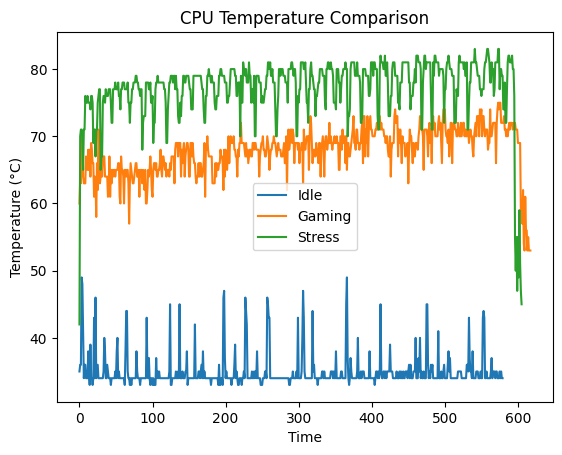

In [33]:
#CPU TEMP GRAPH

plt.figure()
plt.plot(cpu_idle["cpu_temp"], label="Idle")
plt.plot(cpu_gaming["cpu_temp"], label="Gaming")
plt.plot(cpu_stress["cpu_temp"], label="Stress")
plt.title("CPU Temperature Comparison")
plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.show()


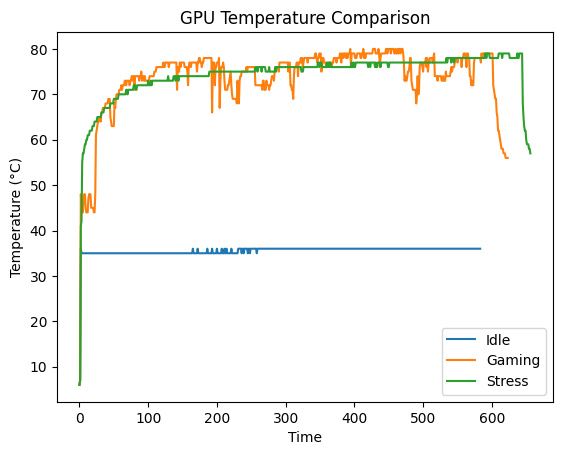

In [34]:
#GPU TEMP GRAPH

plt.figure()
plt.plot(gpu_idle["gpu_temp"], label="Idle")
plt.plot(gpu_gaming["gpu_temp"], label="Gaming")
plt.plot(gpu_stress["gpu_temp"], label="Stress")
plt.title("GPU Temperature Comparison")
plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.legend()
plt.show()


In [35]:
#MAX TEMP SUMMARY

print("CPU Temps:")
print("Idle:", cpu_idle["cpu_temp"].max())
print("Gaming:", cpu_gaming["cpu_temp"].max())
print("Stress:", cpu_stress["cpu_temp"].max())

print("\nGPU Temps:")
print("Idle:", gpu_idle["gpu_temp"].max())
print("Gaming:", gpu_gaming["gpu_temp"].max())
print("Stress:", gpu_stress["gpu_temp"].max())

CPU Temps:
Idle: 49
Gaming: 75
Stress: 83

GPU Temps:
Idle: 36.0
Gaming: 80.0
Stress: 79.0


In [36]:
#ENGINEERING INSIGHTS
print("CPU Temp Increase (Idle → Stress):",
      cpu_stress["cpu_temp"].max() - cpu_idle["cpu_temp"].max())

print("GPU Temp Increase (Idle → Stress):",
      gpu_stress["gpu_temp"].max() - gpu_idle["gpu_temp"].max())

CPU Temp Increase (Idle → Stress): 34
GPU Temp Increase (Idle → Stress): 43.0
